In [1]:
# Data adding (REENA HADIYA (3118))

import pandas as pd
import numpy as np

# Load original dataset
df = pd.read_csv("Iris.csv")

# Remove Id column (important)
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

new_data = []

# Generate 5000 extra rows
for i in range(5000):
    row = df.sample(1).values[0]
    
    new_row = [
        row[0] + np.random.uniform(-0.3, 0.3),
        row[1] + np.random.uniform(-0.3, 0.3),
        row[2] + np.random.uniform(-0.3, 0.3),
        row[3] + np.random.uniform(-0.3, 0.3),
        row[4]
    ]
    
    new_data.append(new_row)

# Convert to DataFrame
new_df = pd.DataFrame(new_data, columns=df.columns)

# Combine original + generated data
final_data = pd.concat([df, new_df], ignore_index=True)

# -------------------------------
#  ADD DUPLICATES
# -------------------------------
duplicates = final_data.sample(30)
final_data = pd.concat([final_data, duplicates], ignore_index=True)

# -------------------------------
#  ADD NULL VALUES
# -------------------------------
for col in final_data.columns[:4]:  # only numeric columns
    final_data.loc[final_data.sample(15).index, col] = np.nan

# Save dataset
final_data.to_csv("iris_large1.csv", index=False)

# Show info
print("Final dataset size:", final_data.shape)
print("\nNull values:\n", final_data.isnull().sum())
print("\nDuplicate rows:", final_data.duplicated().sum())

Final dataset size: (5180, 5)

Null values:
 SepalLengthCm    15
SepalWidthCm     15
PetalLengthCm    15
PetalWidthCm     15
Species           0
dtype: int64

Duplicate rows: 33


In [2]:
# Import Libraries (REENA HADIYA (3118))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform
from scipy.stats import randint

# from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Ensemble Methods Libraries
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, learning_curve

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# DATA COLLECTION  (REENA HADIYA (3118))

print("="*50)
print("STEP 1: DATA COLLECTION")
print("="*50)

# Load Iris dataset
df = pd.read_csv("iris_large1.csv")
df.head()

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nStatistical summary:")
print(df.describe())

STEP 1: DATA COLLECTION
Dataset shape: (5180, 5)

First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5180 entries, 0 to 5179
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  5165 non-null   float64
 1   SepalWidthCm   5165 non-null   float64
 2   PetalLengthCm  5165 non-null   float64
 3   PetalWidthCm   5165 non-null   float64
 4   Species        5180 non-null   object 
dtypes: float64(4), object(1)
memory usage: 202.5+ KB
None

Statistic

In [4]:
#  Data Preprocessing   (SEJAL PARMAR (3153))
print("\n" + "="*50)
print("STEP 2: DATA PREPROCESSING")
print("="*50)

#Shape before removeing duplicate
print(f"Dataset shape before removing duplicates: {df.shape}")

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

#After removing duplicate
print(f"\nDuplicate rows: {df.duplicated().sum()}")


# Check for missing values
print(f"Missing values:\n{df.isnull().sum()}")

#Missing Values Fill Using Mean
#Fill NaN with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Check for missing values after fill
print(f"\nMissing values:\n{df.isnull().sum()}")

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
df




STEP 2: DATA PREPROCESSING
Dataset shape before removing duplicates: (5180, 5)

Duplicate rows: 33
Dataset shape after removing duplicates: (5147, 5)

Duplicate rows: 0
Missing values:
SepalLengthCm    15
SepalWidthCm     15
PetalLengthCm    15
PetalWidthCm     15
Species           0
dtype: int64

Missing values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.100000,3.500000,1.400000,0.200000,0
1,4.900000,3.000000,1.400000,0.200000,0
2,4.700000,3.200000,1.300000,0.200000,0
3,4.600000,3.100000,1.500000,0.200000,0
4,5.000000,3.600000,1.400000,0.200000,0
...,...,...,...,...,...
5145,5.803170,2.896822,3.820564,0.778467,1
5146,6.114835,2.862056,5.364822,2.187207,2
5147,6.997268,3.397394,5.415063,2.347816,2
5148,5.929282,2.635469,4.339150,1.044459,1



STEP 3: DATA VISUALIZATION

1.Pairplot


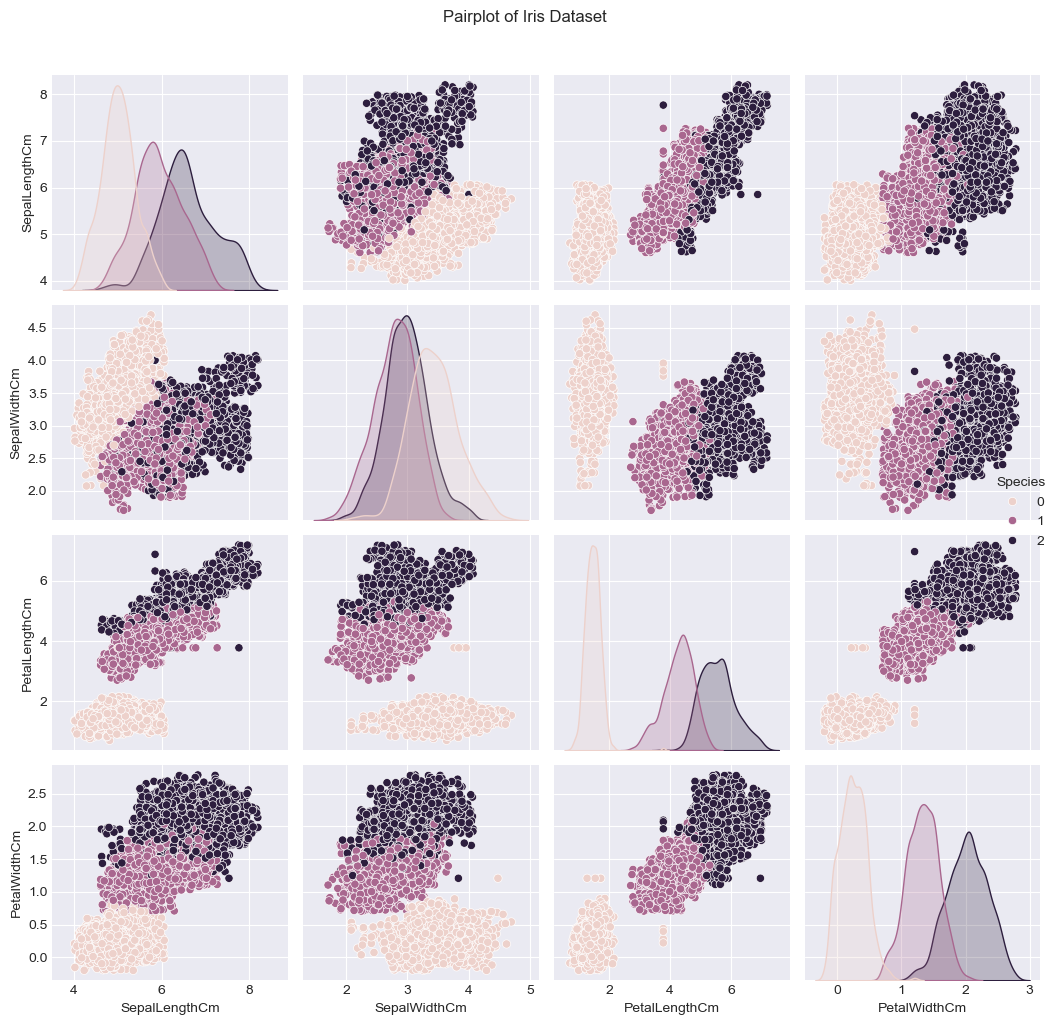

In [5]:
# Exploratory Data Analysis (Visualization) (SEJAL PARMAR (3153))
print("\n" + "="*50)
print("STEP 3: DATA VISUALIZATION")
print("="*50)

# 1. Pairplot
print("\n1.Pairplot")
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.tight_layout()
plt.show()




2.Heatmap


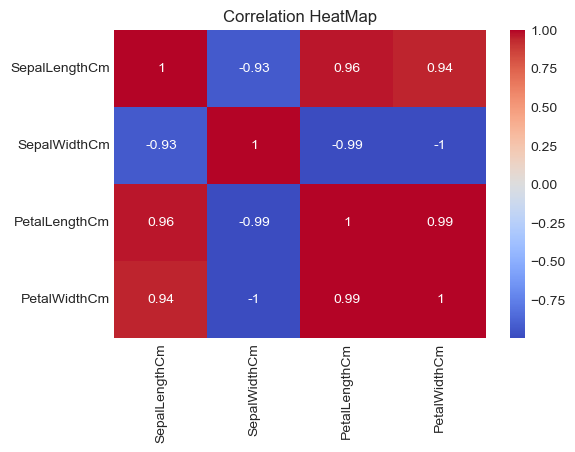

In [6]:
# 2. Correlation Heatmap
print("\n2.Heatmap")
plt.figure(figsize=(6,4))
numeric_cols = df.columns[:-1]  # Exclude species 
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation HeatMap")
plt.show()


3.Box plots


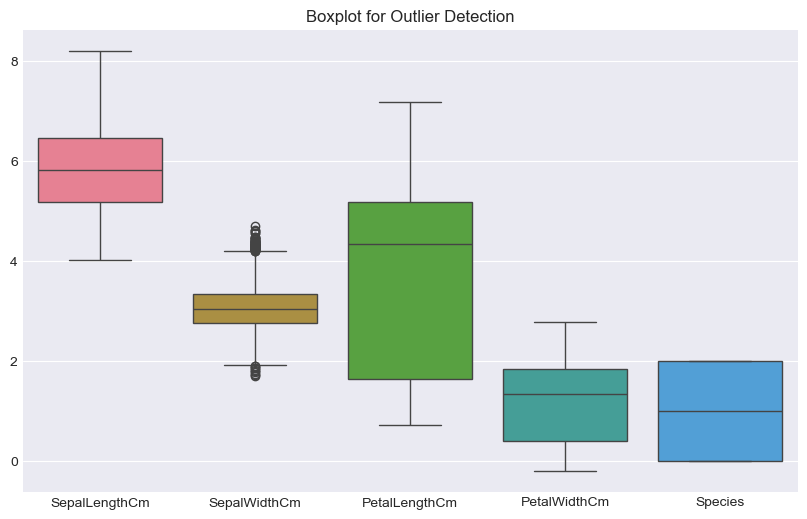

In [7]:
# 3. Box plots for each feature
print("\n3.Box plots")

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()



4.Histogram


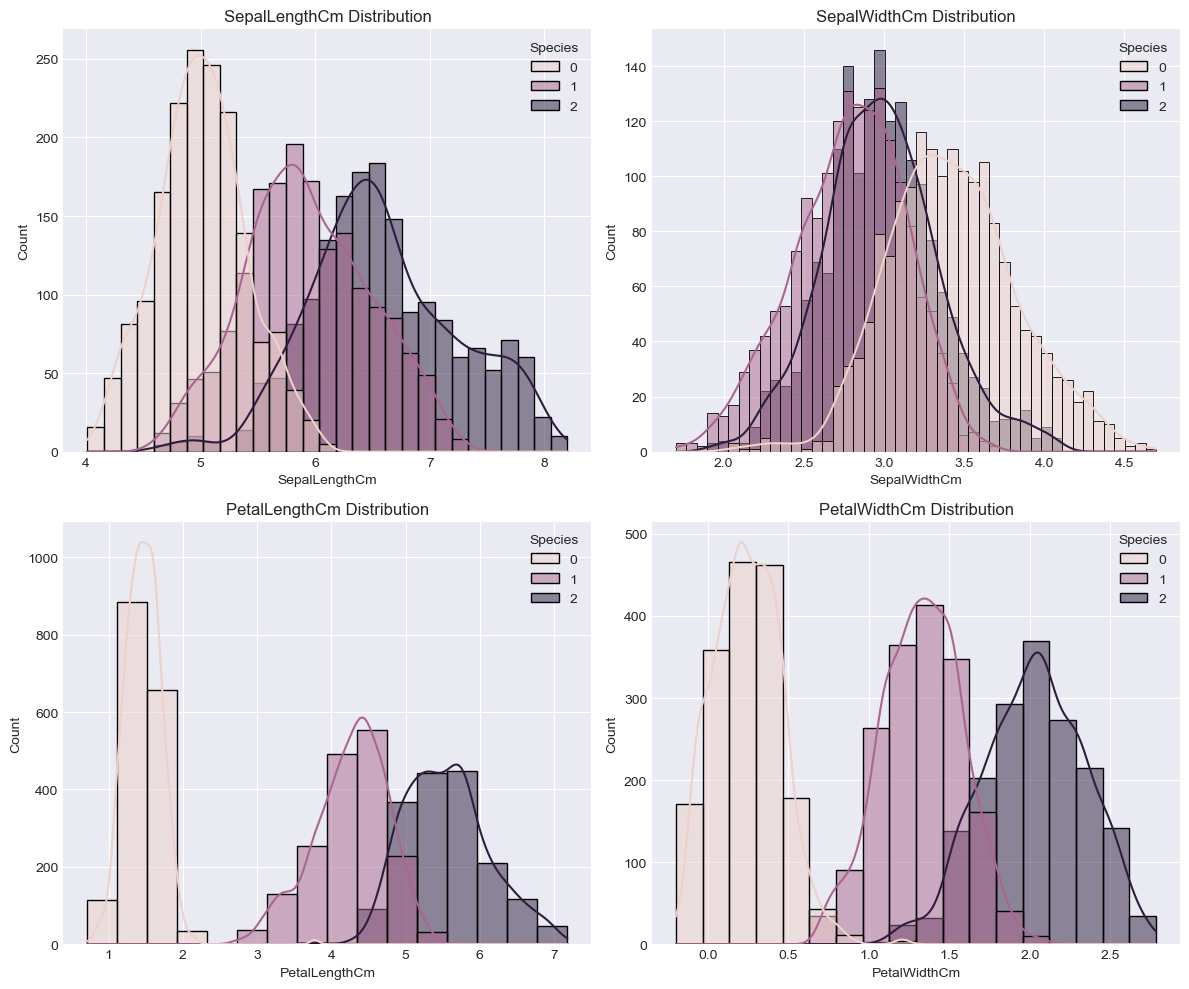

In [8]:
print("\n4.Histogram")

# Create subplots (for multiple graphs)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(numeric_cols):
    ax = axes[i//2, i%2]   # automatically pick correct subplot
    sns.histplot(data=df, x=feature, hue='Species', kde=True, ax=ax)
    ax.set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

In [9]:
# Feature Selection and Train-Test Split (SEJAL PARMAR (3153))
print("\n" + "="*50)
print("STEP 4: FEATURE SELECTION & DATA SPLITTING")
print("="*50)

#Feature Scaling
x = df.drop("Species", axis=1)
y = df['Species']

#TRAIN - TEST SPLIT
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

print(f"\nShape of X_train Data:{X_train.shape}")
print(f"\nShape of X_test Data:{X_test.shape}")



STEP 4: FEATURE SELECTION & DATA SPLITTING

Shape of X_train Data:(4117, 4)

Shape of X_test Data:(1030, 4)


In [10]:
# Standard Scaling  ( SEJAL PARMAR (3153))
print("\n" + "="*50)
print("STEP 5: STANDARD SCALER")
print("="*50)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print(f"Training data shape after scaling: {X_train_scaled.shape}")
print(f"Test data shape after scaling: {X_test_scaled.shape}")
print(f"\nMean after scaling: {X_train_scaled.mean():.2f}")
print(f"Std after scaling: {X_train_scaled.std():.2f}")


STEP 5: STANDARD SCALER
Scaling completed successfully!
Training data shape after scaling: (4117, 4)
Test data shape after scaling: (1030, 4)

Mean after scaling: 0.00
Std after scaling: 1.00



STEP 6: MODEL TRAINING - SVM
SVM Model Performance:
Accuracy: 0.9709
Precision: 0.9709
Recall: 0.9709
F1-Score: 0.9709

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       346
           1       0.95      0.96      0.95       324
           2       0.96      0.95      0.96       360

    accuracy                           0.97      1030
   macro avg       0.97      0.97      0.97      1030
weighted avg       0.97      0.97      0.97      1030



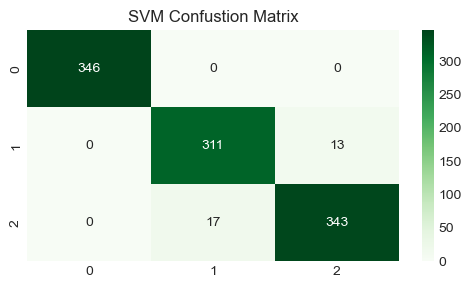

In [11]:
# Cell 7: Model Training - SVM (HARSHITA KALSARIYA (3028))
print("\n" + "="*50)
print("STEP 6: MODEL TRAINING - SVM")
print("="*50)

# Initialize SVM model
svm_model = SVC(random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_scaled)

# Evaluate SVM
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print(f"SVM Model Performance:")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test,svm_pred))

plt.figure(figsize=(6,3))
sns.heatmap(confusion_matrix(y_test, svm_pred),annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confustion Matrix")
plt.show()


STEP 7: MODEL TRAINING - KNN
KNN Model Performance:
Accuracy: 0.9660
Precision: 0.9661
Recall: 0.9660
F1-Score: 0.9660

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       346
           1       0.94      0.95      0.95       324
           2       0.96      0.94      0.95       360

    accuracy                           0.97      1030
   macro avg       0.97      0.97      0.97      1030
weighted avg       0.97      0.97      0.97      1030



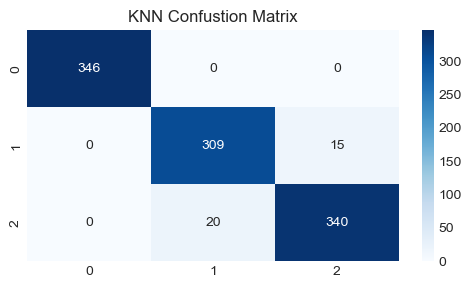

In [12]:
# Cell 8: Model Training - KNN (HARSHITA KLASARIYA (3028))
print("\n" + "="*50)
print("STEP 7: MODEL TRAINING - KNN")
print("="*50)

# Initialize KNN model
knn_model = KNeighborsClassifier()

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predictions
knn_pred = knn_model.predict(X_test_scaled)

# Evaluate KNN
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print(f"KNN Model Performance:")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test,knn_pred))

plt.figure(figsize=(6,3))
sns.heatmap(confusion_matrix(y_test, knn_pred),annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confustion Matrix")
plt.show()

In [13]:
# Hyperparameter Tuning ( REENA HADIYA (3118))
print("\n" + "="*50)
print("STEP 9: HYPERPARAMETER TUNING")
print("="*50)

# SVM Hyperparameter Tuning
print("\nTuning SVM Hyperparameters...")
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid_search = GridSearchCV(
    SVC(random_state=42),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid_search.fit(X_train_scaled, y_train)
print("\nBy GridSearchCV...")
print(f"SVM Best Parameters: {svm_grid_search.best_params_}")
print(f"SVM Best Score: {svm_grid_search.best_score_:.4f}")

param_dist_svm = {
    'C': uniform(0.1, 100),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

rand_svm = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist_svm,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

rand_svm.fit(X_train, y_train)
print("\nBy RandomizedSearchCV...")
print("Best Random SVM Params:", rand_svm.best_params_)
print(f"Best Random SVM Score: {rand_svm.best_score_:.4f}")

# KNN Hyperparameter Tuning
print("\nTuning KNN Hyperparameters...")
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
knn_grid_search.fit(X_train_scaled, y_train)

print("\nBy GridSearchCV... ")
print(f"KNN Best Parameters: {knn_grid_search.best_params_}")
print(f"KNN Best Score: {knn_grid_search.best_score_:.4f}")

param_dist_knn = {
    'n_neighbors': randint(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

rand_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)
rand_knn.fit(X_train, y_train)

print("\nBy RandomizedSearchCV...")
print("Best Random KNN Params:", rand_knn.best_params_)
print(f"Best Random KNN Score: {rand_knn.best_score_:.4f}")


STEP 9: HYPERPARAMETER TUNING

Tuning SVM Hyperparameters...

By GridSearchCV...
SVM Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best Score: 0.9679

By RandomizedSearchCV...
Best Random SVM Params: {'C': np.float64(83.34426408004217), 'gamma': 'auto', 'kernel': 'rbf'}
Best Random SVM Score: 0.9692

Tuning KNN Hyperparameters...

By GridSearchCV... 
KNN Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
KNN Best Score: 0.9689

By RandomizedSearchCV...
Best Random KNN Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best Random KNN Score: 0.9692


In [14]:
# Train Final Models with Best Parameters ( HARSHITA KALSARIYA  (3028))
print("\n" + "="*50)
print("STEP 10: TRAIN FINAL MODELS WITH BEST PARAMETERS")
print("="*50)

# Train final SVM model
final_svm = SVC(**svm_grid_search.best_params_, random_state=42)
final_svm.fit(X_train_scaled, y_train)
final_svm_pred = final_svm.predict(X_test_scaled)
final_svm_accuracy = accuracy_score(y_test, final_svm_pred)

# Train final KNN model
final_knn = KNeighborsClassifier(**knn_grid_search.best_params_)
final_knn.fit(X_train_scaled, y_train)
final_knn_pred = final_knn.predict(X_test_scaled)
final_knn_accuracy = accuracy_score(y_test, final_knn_pred)

print(f"Final SVM Accuracy: {final_svm_accuracy:.4f}")
print(f"Final KNN Accuracy: {final_knn_accuracy:.4f}")



STEP 10: TRAIN FINAL MODELS WITH BEST PARAMETERS
Final SVM Accuracy: 0.9718
Final KNN Accuracy: 0.9621


In [15]:
# Save Models and Scaler (SEJAL PARMAR (3153))
print("\n" + "="*50)
print("STEP 12: SAVE MODELS AND SCALER")
print("="*50)

# Create models directory
import os
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(final_svm, 'models/svm_model.pkl')
joblib.dump(final_knn, 'models/knn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Models and scaler saved successfully!")
print("Files saved in 'models/' directory")


STEP 12: SAVE MODELS AND SCALER
Models and scaler saved successfully!
Files saved in 'models/' directory


In [16]:
#  Model Summary Report ( HARSHITA KALSARIYA (3028))
print("\n" + "="*50)
print("FINAL REPORT - MODEL SUMMARY")
print("="*50)

print("\nBest Models Performance:")
print("-" * 40)
print(f"SVM Model:")
print(f"  Best Parameters: {svm_grid_search.best_params_}")
print(f"  Test Accuracy: {final_svm_accuracy:.4f}")
print(f"  Cross-validation Score: {svm_grid_search.best_score_:.4f}")

print(f"\nKNN Model:")
print(f"  Best Parameters: {knn_grid_search.best_params_}")
print(f"  Test Accuracy: {final_knn_accuracy:.4f}")
print(f"  Cross-validation Score: {knn_grid_search.best_score_:.4f}")

print(f"\nRecommended Model: {'SVM' if final_svm_accuracy > final_knn_accuracy else 'KNN'}")
print(f"Best Accuracy Achieved: {max(final_svm_accuracy, final_knn_accuracy):.4f}")


FINAL REPORT - MODEL SUMMARY

Best Models Performance:
----------------------------------------
SVM Model:
  Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Test Accuracy: 0.9718
  Cross-validation Score: 0.9679

KNN Model:
  Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
  Test Accuracy: 0.9621
  Cross-validation Score: 0.9689

Recommended Model: SVM
Best Accuracy Achieved: 0.9718


In [17]:
# Initialize Ensemble Models with default parameters
print("Initializing Ensemble Models...")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)



ensemble_models = {
    'Random Forest': rf_model,
    'AdaBoost': ada_model
}

print("✅ Models initialized successfully!")

Initializing Ensemble Models...
✅ Models initialized successfully!


In [18]:
# Train and evaluate all ensemble models
results = {}

print("="*60)
print("TRAINING ENSEMBLE MODELS")
print("="*60)

for name, model in ensemble_models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}")
    
    # Display classification report
    print(f"\n📊 {name} Classification Report:")
    print(classification_report(y_test, y_pred))


print("✅ All ensemble models trained successfully!")


TRAINING ENSEMBLE MODELS

Training Random Forest...
✅ Random Forest - Accuracy: 0.9709

📊 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       346
           1       0.95      0.96      0.95       324
           2       0.97      0.95      0.96       360

    accuracy                           0.97      1030
   macro avg       0.97      0.97      0.97      1030
weighted avg       0.97      0.97      0.97      1030


Training AdaBoost...
✅ AdaBoost - Accuracy: 0.9485

📊 AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       346
           1       0.92      0.92      0.92       324
           2       0.93      0.93      0.93       360

    accuracy                           0.95      1030
   macro avg       0.95      0.95      0.95      1030
weighted avg       0.95      0.95      0.95      1030

✅ All ensemble models tr

In [19]:
# Cross-validation to monitor model stability
print("\n🔍 PERFORMING CROSS-VALIDATION (5-fold)")
print("-"*50)

cv_results = {}

for name, model in ensemble_models.items():
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(
        model, 
        X_train_scaled, 
        y_train, 
        cv=5, 
        scoring='accuracy'
    )
    
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    
    print(f"\n{name}:")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  Std Deviation: {cv_scores.std():.4f}")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Stability: {'✅ Stable' if cv_scores.std() < 0.03 else '⚠️ Needs Tuning'}")

# # Visualize cross-validation results
# plt.figure(figsize=(10, 6))
# cv_data = pd.DataFrame({name: cv_results[name]['scores'] for name in cv_results.keys()})
# cv_data.boxplot()
# plt.title('Cross-Validation Accuracy Distribution (5-fold)')
# plt.ylabel('Accuracy')
# plt.xlabel('Models')
# plt.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


🔍 PERFORMING CROSS-VALIDATION (5-fold)
--------------------------------------------------

Random Forest:
  Mean Accuracy: 0.9682
  Std Deviation: 0.0046
  CV Scores: [0.97572816 0.96237864 0.9708384  0.96597813 0.96597813]
  Stability: ✅ Stable

AdaBoost:
  Mean Accuracy: 0.9512
  Std Deviation: 0.0031
  CV Scores: [0.95145631 0.95024272 0.95625759 0.94653706 0.95139733]
  Stability: ✅ Stable
